# Face Modality — Drowsiness MLP from MediaPipe Features

**Driver Fatigue Detection — Signal Modality Comparison**
*BSc Computing Dissertation — Leon Dupree*

This notebook trains and evaluates a small MLP that classifies face images
as **alert** or **drowsy** using engineered features extracted from MediaPipe
facial landmarks. The model takes per-image engineered features as input —
not raw pixels — which keeps it methodologically consistent with the voice
and steering modalities (also engineered features → MLP), differing only
from the eye modality which operates on raw pixels via a CNN.

**Dataset:** Driver Drowsiness Dataset (DDD) — Kaggle by *ismailnasri20*.
Frame-level images extracted from drowsiness driving footage, organised into
`Drowsy/` and `Non Drowsy/` folders. Hosted at:
https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd

**Features extracted per image:**
- Head pose: pitch, yaw, roll angles (degrees) — derived via solvePnP
- MAR (Mouth Aspect Ratio) — open-mouth indicator (yawning)
- EAR (Eye Aspect Ratio) — average across both eyes, eye-openness indicator
- Inter-eye distance (normalised) — face scale reference

**Methodology notes:**
- This dataset does not include subject IDs in filenames, so a random
  image-level split is used. This is documented as a methodological
  limitation (see §3.3 / §5.7 of the dissertation).
- MediaPipe FaceLandmarker may fail to detect a face in some images;
  these are dropped from the dataset before training.
- Reported metrics: accuracy, precision, recall, F1-score, confusion matrix.


## 1. Setup and imports

In [3]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import cv2
import mediapipe as mp

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split

# Make src/ importable
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.face.model import FaceMLP

print(f"PyTorch:  {torch.__version__}")
print(f"OpenCV:   {cv2.__version__}")
print(f"MediaPipe: {mp.__version__}")
print(f"CUDA:     {torch.cuda.is_available()}")


PyTorch:  2.5.1+cu121
OpenCV:   4.13.0
MediaPipe: 0.10.33
CUDA:     True


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Download MediaPipe FaceLandmarker model

The face landmarker model file (~3 MB) needs to be downloaded once and saved
to `models/face_landmarker.task`. This cell handles that automatically.


In [5]:
import urllib.request

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
    "face_landmarker/float16/latest/face_landmarker.task"
)
LANDMARKER_PATH = PROJECT_ROOT / "models" / "face_landmarker.task"

if not LANDMARKER_PATH.exists():
    print(f"Downloading MediaPipe face landmarker model...")
    LANDMARKER_PATH.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(MODEL_URL, str(LANDMARKER_PATH))
    print(f"Saved to: {LANDMARKER_PATH}")
else:
    print(f"Model already present: {LANDMARKER_PATH}")

print(f"Size: {LANDMARKER_PATH.stat().st_size / 1024 / 1024:.2f} MB")


Saved to: C:\Dissertation\fatigue-detection\models\face_landmarker.task
Size: 3.58 MB


## 3. Locate the dataset

### Expected folder structure

Download the **Driver Drowsiness Dataset (DDD)** from Kaggle and extract it
into the `data/` folder. The notebook accepts a few common folder names that
Kaggle uploads use:

```
fatigue-detection/data/
└── ddd_face/
    ├── Drowsy/         (or "drowsy")
    │   └── *.jpg / *.png
    └── Non Drowsy/     (or "non_drowsy" / "NonDrowsy")
        └── *.jpg / *.png
```

If your extracted folder is named differently (e.g. `archive`, `Driver Drowsiness Dataset (DDD)`),
just rename it to `ddd_face` or update the path below.

**Direct download link:**
https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd


In [6]:
DATA_ROOT = PROJECT_ROOT / "data"

# Find the dataset folder (try common names)
candidates = [
    DATA_ROOT / "ddd_face",
    DATA_ROOT / "DDD",
    DATA_ROOT / "Driver Drowsiness Dataset (DDD)",
    DATA_ROOT / "archive",
]
DATA_DIR = next((d for d in candidates if d.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Face dataset not found. Looked in: " +
        ", ".join(str(d) for d in candidates) +
        "\nDownload from https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd"
    )

# Find the two label folders. Accept several capitalisations.
def find_subfolder(root: Path, options: list[str]) -> Path | None:
    for name in options:
        for child in root.rglob(name):
            if child.is_dir():
                return child
    return None

drowsy_dir     = find_subfolder(DATA_DIR, ["Drowsy", "drowsy", "DROWSY"])
non_drowsy_dir = find_subfolder(DATA_DIR, ["Non Drowsy", "Non_Drowsy", "NonDrowsy",
                                            "non_drowsy", "non drowsy", "Awake", "awake"])

if drowsy_dir is None or non_drowsy_dir is None:
    raise FileNotFoundError(
        f"Could not find Drowsy and/or Non-Drowsy subfolders inside {DATA_DIR}.\n"
        f"Found: drowsy_dir={drowsy_dir}, non_drowsy_dir={non_drowsy_dir}"
    )

print(f"Dataset root: {DATA_DIR}")
print(f"  Drowsy folder:     {drowsy_dir}")
print(f"  Non-drowsy folder: {non_drowsy_dir}")

# Count images
exts = {".jpg", ".jpeg", ".png", ".bmp"}
drowsy_files     = sorted([p for p in drowsy_dir.rglob("*") if p.suffix.lower() in exts])
non_drowsy_files = sorted([p for p in non_drowsy_dir.rglob("*") if p.suffix.lower() in exts])
print(f"  Drowsy images:     {len(drowsy_files):,}")
print(f"  Non-drowsy images: {len(non_drowsy_files):,}")
print(f"  Total:             {len(drowsy_files) + len(non_drowsy_files):,}")


Dataset root: C:\Dissertation\fatigue-detection\data\Driver Drowsiness Dataset (DDD)
  Drowsy folder:     C:\Dissertation\fatigue-detection\data\Driver Drowsiness Dataset (DDD)\Drowsy
  Non-drowsy folder: C:\Dissertation\fatigue-detection\data\Driver Drowsiness Dataset (DDD)\Non Drowsy
  Drowsy images:     22,348
  Non-drowsy images: 19,445
  Total:             41,793


## 4. Feature extraction with MediaPipe

For each image, we run MediaPipe's face landmarker and compute:

| Feature | Description |
|---------|-------------|
| `pitch`, `yaw`, `roll` | Head pose angles in degrees, derived from solvePnP |
| `mar` | Mouth Aspect Ratio (vertical mouth opening / mouth width) |
| `ear_avg` | Eye Aspect Ratio averaged across left and right eyes |
| `eye_distance_norm` | Distance between eye centres, normalised by face height |

Images where MediaPipe fails to detect a face are dropped.

**This is the slow step** — it processes every image in the dataset.
Features are cached to `data/face_features.csv` so re-running the notebook
skips this work next time.


In [22]:
# Landmark indices (MediaPipe FaceMesh / FaceLandmarker — 468 face landmarks)
POSE_LANDMARKS = {
    "nose": 1, "chin": 152,
    "left_eye": 33, "right_eye": 263,
    "left_mouth": 61, "right_mouth": 291,
}
MAR_POINTS = {"left_corner": 61, "right_corner": 291, "upper": 13, "lower": 14}
# EAR landmarks (6 points per eye in MediaPipe convention)
LEFT_EYE_EAR  = [33, 160, 158, 133, 153, 144]
RIGHT_EYE_EAR = [263, 387, 385, 362, 380, 373]


def lm_xy(lms, idx, w, h):
    lm = lms[idx]
    return np.array([lm.x * w, lm.y * h], dtype=np.float64)


def dist(a, b):
    return float(np.linalg.norm(a - b))


def rotation_vector_to_euler(rvec):
    R, _ = cv2.Rodrigues(rvec)
    sy = np.sqrt(R[0, 0] ** 2 + R[1, 0] ** 2)
    if sy >= 1e-6:
        x = np.arctan2(R[2, 1], R[2, 2])
        y = np.arctan2(-R[2, 0], sy)
        z = np.arctan2(R[1, 0], R[0, 0])
    else:
        x = np.arctan2(-R[1, 2], R[1, 1])
        y = np.arctan2(-R[2, 0], sy)
        z = 0.0
    pitch, yaw, roll = np.degrees([x, y, z])
    pitch = ((pitch + 180) % 360) - 180   # stabilise pitch wrap
    return float(pitch), float(yaw), float(roll)


def estimate_head_pose(lms, w, h):
    image_points = np.array([
        lm_xy(lms, POSE_LANDMARKS["nose"], w, h),
        lm_xy(lms, POSE_LANDMARKS["chin"], w, h),
        lm_xy(lms, POSE_LANDMARKS["left_eye"], w, h),
        lm_xy(lms, POSE_LANDMARKS["right_eye"], w, h),
        lm_xy(lms, POSE_LANDMARKS["left_mouth"], w, h),
        lm_xy(lms, POSE_LANDMARKS["right_mouth"], w, h),
    ])
    model_points = np.array([
        (0.0, 0.0, 0.0),
        (0.0, -63.6, -12.5),
        (-43.3, 32.7, -26.0),
        (43.3, 32.7, -26.0),
        (-28.9, -28.9, -24.1),
        (28.9, -28.9, -24.1),
    ])
    focal = w
    cam = np.array([[focal, 0, w / 2], [0, focal, h / 2], [0, 0, 1]], dtype=np.float64)
    ok, rvec, _ = cv2.solvePnP(model_points, image_points, cam, np.zeros((4, 1)))
    if not ok:
        return None
    return rotation_vector_to_euler(rvec)


def compute_mar(lms, w, h):
    left  = lm_xy(lms, MAR_POINTS["left_corner"], w, h)
    right = lm_xy(lms, MAR_POINTS["right_corner"], w, h)
    upper = lm_xy(lms, MAR_POINTS["upper"], w, h)
    lower = lm_xy(lms, MAR_POINTS["lower"], w, h)
    width = dist(left, right)
    return 0.0 if width < 1e-6 else dist(upper, lower) / width


def compute_ear(lms, eye_indices, w, h):
    p = [lm_xy(lms, i, w, h) for i in eye_indices]
    # Standard EAR: (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)
    width = dist(p[0], p[3])
    return 0.0 if width < 1e-6 else (dist(p[1], p[5]) + dist(p[2], p[4])) / (2.0 * width)


def extract_features_one_image(landmarker, image_path: Path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_img)
    if not result.face_landmarks:
        return None
    lms = result.face_landmarks[0]

    pose = estimate_head_pose(lms, w, h)
    if pose is None:
        return None
    pitch, yaw, roll = pose

    mar = compute_mar(lms, w, h)
    ear_left  = compute_ear(lms, LEFT_EYE_EAR, w, h)
    ear_right = compute_ear(lms, RIGHT_EYE_EAR, w, h)
    ear_avg = (ear_left + ear_right) / 2.0

    # Normalised inter-eye distance (face-scale invariant)
    eye_dist = dist(lm_xy(lms, 33, w, h), lm_xy(lms, 263, w, h)) / max(h, 1)

    return {
        "pitch": pitch, "yaw": yaw, "roll": roll,
        "mar": mar, "ear_avg": ear_avg,
        "eye_distance_norm": eye_dist,
    }


In [23]:
# Optional sub-sampling: large datasets can take a long time to extract.
# Set to None to use everything, or to an integer for a per-class cap.
MAX_IMAGES_PER_CLASS = 4000

CACHE_PATH = DATA_ROOT / "face_features.csv"

def build_or_load_features():
    if CACHE_PATH.exists():
        print(f"Loading cached features from {CACHE_PATH}")
        return pd.read_csv(CACHE_PATH)

    drowsy_set     = drowsy_files
    non_drowsy_set = non_drowsy_files
    if MAX_IMAGES_PER_CLASS is not None:
        rng_local = np.random.default_rng(SEED)
        if len(drowsy_set) > MAX_IMAGES_PER_CLASS:
            drowsy_set = list(rng_local.choice(drowsy_set, MAX_IMAGES_PER_CLASS, replace=False))
        if len(non_drowsy_set) > MAX_IMAGES_PER_CLASS:
            non_drowsy_set = list(rng_local.choice(non_drowsy_set, MAX_IMAGES_PER_CLASS, replace=False))

    print(f"Extracting features from {len(drowsy_set):,} drowsy + {len(non_drowsy_set):,} non-drowsy images...")

    BaseOptions = mp.tasks.BaseOptions
    FaceLandmarker = mp.tasks.vision.FaceLandmarker
    FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
    VisionRunningMode = mp.tasks.vision.RunningMode
    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(LANDMARKER_PATH)),
        running_mode=VisionRunningMode.IMAGE,
        num_faces=1,
    )

    rows = []
    failures = 0
    with FaceLandmarker.create_from_options(options) as landmarker:
        for label, files in [(1, drowsy_set), (0, non_drowsy_set)]:
            label_name = "drowsy" if label == 1 else "non_drowsy"
            for p in tqdm(files, desc=label_name, leave=True):
                feats = extract_features_one_image(landmarker, p)
                if feats is None:
                    failures += 1
                    continue
                feats["label"] = label
                feats["path"] = str(p)
                rows.append(feats)

    df_local = pd.DataFrame(rows)
    df_local.to_csv(CACHE_PATH, index=False)
    print(f"\nExtracted features for {len(df_local):,} images")
    print(f"Detection failures: {failures} (face not found / pose failed)")
    print(f"Cached to: {CACHE_PATH}")
    return df_local


df = build_or_load_features()
print(f"\nDataFrame shape: {df.shape}")
print(f"\nClass balance:")
print(df["label"].value_counts().rename({0: "non_drowsy", 1: "drowsy"}))
df.head()


Loading cached features from C:\Dissertation\fatigue-detection\data\face_features.csv

DataFrame shape: (7995, 8)

Class balance:
label
non_drowsy    3998
drowsy        3997
Name: count, dtype: int64


,pitch,yaw,roll,mar,ear_avg,eye_distance_norm,label,path
0,-174.378171,4.302496,1.772324,0.006946,0.172550,0.632097,1,C:\Dissertation\fatigue-detection\data\Driver ...
1,-179.189527,1.463237,2.163743,0.002488,0.223230,0.555935,1,C:\Dissertation\fatigue-detection\data\Driver ...
2,-171.077949,3.346962,-0.525998,0.004311,0.265837,0.603700,1,C:\Dissertation\fatigue-detection\data\Driver ...
3,167.146761,-5.513819,3.029522,0.010930,0.205317,0.481710,1,C:\Dissertation\fatigue-detection\data\Driver ...
4,166.044057,-5.660322,3.636231,0.002306,0.187279,0.565337,1,C:\Dissertation\fatigue-detection\data\Driver ...


## 5. Feature inspection

Quick sanity check: the feature distributions should differ between drowsy
and non-drowsy classes if the features are informative. We plot histograms
per feature to see whether there's separation.


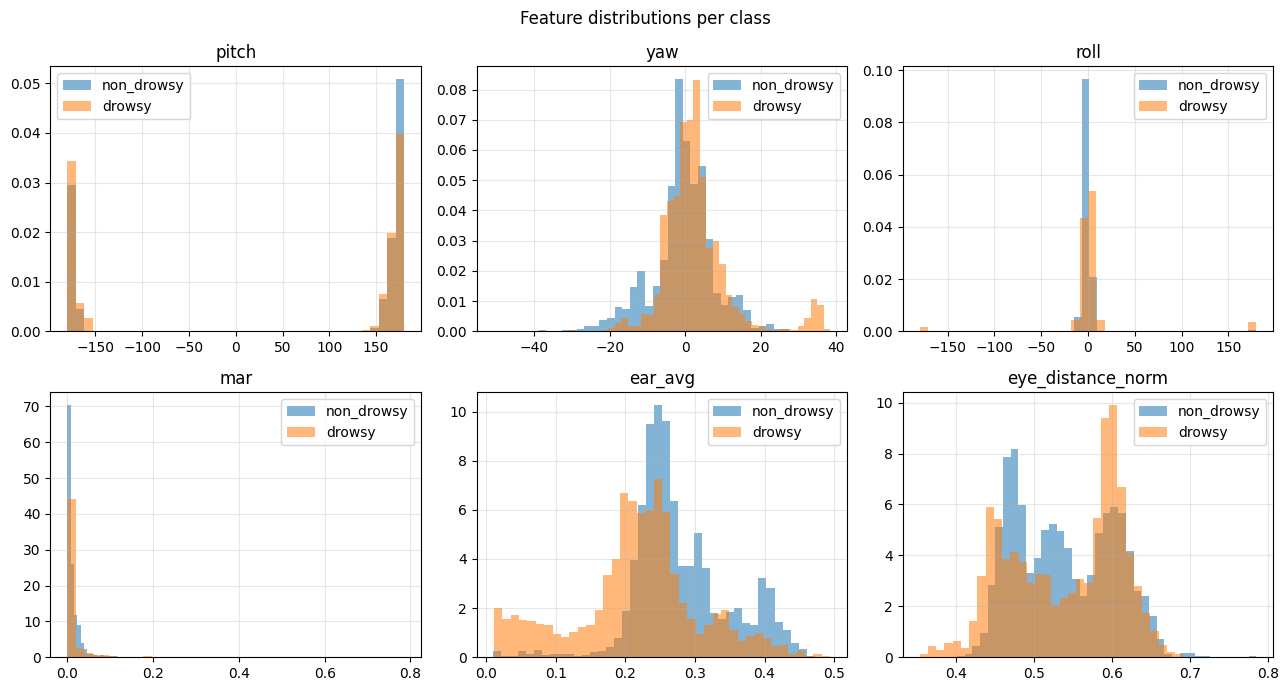

In [24]:
FEATURE_COLS = ["pitch", "yaw", "roll", "mar", "ear_avg", "eye_distance_norm"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flatten(), FEATURE_COLS):
    drowsy_vals     = df.loc[df.label == 1, col]
    non_drowsy_vals = df.loc[df.label == 0, col]
    ax.hist(non_drowsy_vals, bins=40, alpha=0.55, label="non_drowsy", density=True)
    ax.hist(drowsy_vals,     bins=40, alpha=0.55, label="drowsy",     density=True)
    ax.set_title(col); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Feature distributions per class")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "face_feature_distributions.png", dpi=120)
plt.show()


## 6. Train / validation / test split

The DDD dataset does not include subject IDs, so we use a stratified random
70/15/15 split at the image level. This is a methodological limitation
compared to the eye modality (which uses subject-level splits) and is
documented in the dissertation methodology and limitations sections.


In [25]:
X = df[FEATURE_COLS].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.int64)

# 70 / 15 / 15 split, stratified by label
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, random_state=SEED, stratify=y_tv
)

# Standardise using training set statistics
mu  = X_train.mean(axis=0, keepdims=True)
sig = X_train.std(axis=0, keepdims=True) + 1e-6
X_train = (X_train - mu) / sig
X_val   = (X_val - mu) / sig
X_test  = (X_test - mu) / sig

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"\nTrain class balance: {np.bincount(y_train)}")
print(f"Val class balance:   {np.bincount(y_val)}")
print(f"Test class balance:  {np.bincount(y_test)}")


Train: 5,595  Val: 1,200  Test: 1,200

Train class balance: [2798 2797]
Val class balance:   [600 600]
Test class balance:  [600 600]


In [26]:
# Convert to torch tensors and DataLoaders
def make_loader(X_arr, y_arr, batch_size, shuffle):
    ds = TensorDataset(torch.tensor(X_arr), torch.tensor(y_arr))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 128
train_dl = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_dl   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_dl  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)


## 7. Model and training

The MLP architecture is defined in `src/face/model.py`. It takes the
standardised features and outputs 2 class logits.


In [27]:
N_FEATURES = X_train.shape[1]
model = FaceMLP(n_features=N_FEATURES, num_classes=2, dropout=0.25).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {model.count_parameters():,}")


FaceMLP(
  (classifier): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=16, out_features=2, bias=True)
  )
)

Trainable parameters: 786


In [28]:
EPOCHS = 30
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
BEST_WEIGHTS_PATH = MODELS_DIR / "face_mlp.pt"

# Also save normalisation stats so we can replay this transformation at inference
np.save(MODELS_DIR / "face_mlp_norm_mu.npy",  mu.squeeze())
np.save(MODELS_DIR / "face_mlp_norm_sig.npy", sig.squeeze())

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, total_correct, total_n = 0.0, 0, 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = loss_fn(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n += x.size(0)
    return total_loss / total_n, total_correct / total_n


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_dl, training=True)
    val_loss, val_acc = run_epoch(val_dl, training=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_WEIGHTS_PATH)
        marker = "  <- best, saved"

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.3f}")
print(f"Saved best weights to: {BEST_WEIGHTS_PATH}")


Epoch  1/30  train_loss=0.6385 train_acc=0.661  val_loss=0.6005 val_acc=0.720  <- best, saved
Epoch  2/30  train_loss=0.5715 train_acc=0.716  val_loss=0.5543 val_acc=0.731  <- best, saved
Epoch  3/30  train_loss=0.5365 train_acc=0.735  val_loss=0.5359 val_acc=0.739  <- best, saved
Epoch  4/30  train_loss=0.5250 train_acc=0.753  val_loss=0.5246 val_acc=0.757  <- best, saved
Epoch  5/30  train_loss=0.5162 train_acc=0.753  val_loss=0.5148 val_acc=0.773  <- best, saved
Epoch  6/30  train_loss=0.5103 train_acc=0.756  val_loss=0.5056 val_acc=0.777  <- best, saved
Epoch  7/30  train_loss=0.5043 train_acc=0.763  val_loss=0.5009 val_acc=0.784  <- best, saved
Epoch  8/30  train_loss=0.4994 train_acc=0.760  val_loss=0.4969 val_acc=0.786  <- best, saved
Epoch  9/30  train_loss=0.4948 train_acc=0.763  val_loss=0.4891 val_acc=0.788  <- best, saved
Epoch 10/30  train_loss=0.4878 train_acc=0.766  val_loss=0.4833 val_acc=0.787
Epoch 11/30  train_loss=0.4892 train_acc=0.767  val_loss=0.4833 val_acc=0.79

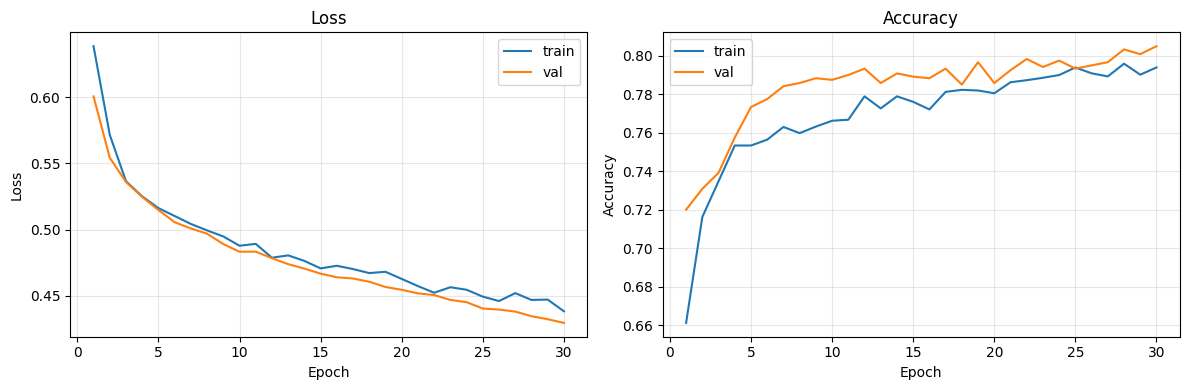

In [29]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_x, history["train_loss"], label="train")
ax1.plot(epochs_x, history["val_loss"], label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_x, history["train_acc"], label="train")
ax2.plot(epochs_x, history["val_acc"], label="val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "face_training_curves.png", dpi=120)
plt.show()


## 8. Test set evaluation

Load the best weights and evaluate on the held-out test set. These are the
numbers that go in the dissertation.


In [30]:
model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())   # P(drowsy)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=1
)

print(f"Test set: {len(all_labels):,} images")
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  (positive class = drowsy)")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n" + classification_report(
    all_labels, all_preds, target_names=["non_drowsy", "drowsy"], digits=4
))


Test set: 1,200 images

Accuracy:  0.7825
Precision: 0.7888  (positive class = drowsy)
Recall:    0.7717
F1-score:  0.7801

              precision    recall  f1-score   support

  non_drowsy     0.7765    0.7933    0.7848       600
      drowsy     0.7888    0.7717    0.7801       600

    accuracy                         0.7825      1200
   macro avg     0.7826    0.7825    0.7825      1200
weighted avg     0.7826    0.7825    0.7825      1200



C:\Users\leonf\AppData\Local\Temp\ipykernel_3836\2512791386.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_locat

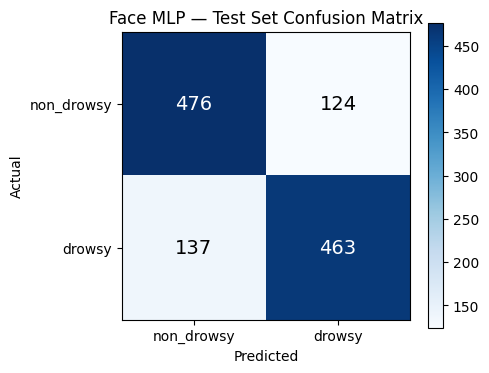

In [31]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["non_drowsy", "drowsy"])
ax.set_yticklabels(["non_drowsy", "drowsy"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Face MLP — Test Set Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "face_confusion_matrix.png", dpi=120)
plt.show()


## 9. Feature importance (permutation)

Which features contribute most to the prediction? We measure this with
permutation importance: for each feature in turn, shuffle its values across
the test set and measure how much accuracy drops. The biggest drops are the
most important features.

This is direct material for the dissertation Discussion section.


Base test accuracy: 0.7825

Permutation importance (drop in accuracy when feature is shuffled):
               ear_avg: +0.2072 ± 0.0057
     eye_distance_norm: +0.1075 ± 0.0096
                   yaw: +0.0688 ± 0.0065
                 pitch: +0.0418 ± 0.0091
                  roll: +0.0168 ± 0.0027
                   mar: +0.0122 ± 0.0008


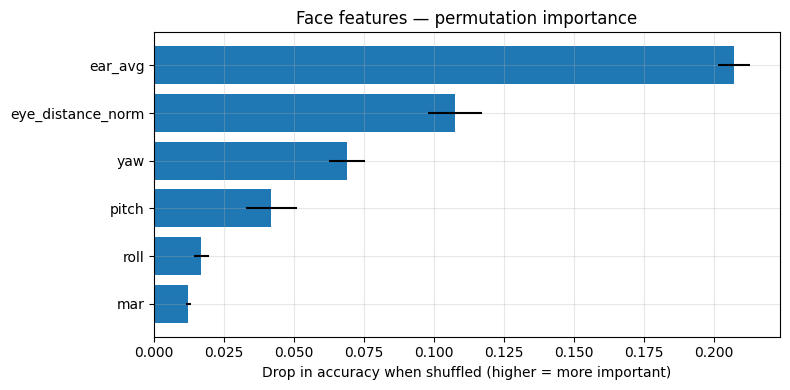

In [32]:
def permutation_importance(model, X, y, n_repeats=5):
    model.eval()
    rng_local = np.random.default_rng(SEED)

    def acc_of(X_arr):
        with torch.no_grad():
            preds = model(torch.tensor(X_arr).to(DEVICE)).argmax(1).cpu().numpy()
        return float((preds == y).mean())

    base = acc_of(X)
    drops = {}
    for j, name in enumerate(FEATURE_COLS):
        ds = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            rng_local.shuffle(X_perm[:, j])
            ds.append(base - acc_of(X_perm))
        drops[name] = (float(np.mean(ds)), float(np.std(ds)))
    return base, drops


base_acc, importances = permutation_importance(model, X_test, y_test)
print(f"Base test accuracy: {base_acc:.4f}\n")

names = list(importances.keys())
means = [importances[n][0] for n in names]
stds  = [importances[n][1] for n in names]

order = np.argsort(means)[::-1]   # most important first

print("Permutation importance (drop in accuracy when feature is shuffled):")
for i in order:
    print(f"  {names[i]:>20s}: {means[i]:+.4f} ± {stds[i]:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([names[i] for i in order[::-1]], [means[i] for i in order[::-1]],
        xerr=[stds[i] for i in order[::-1]])
ax.set_xlabel("Drop in accuracy when shuffled (higher = more important)")
ax.set_title("Face features — permutation importance")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "face_feature_importance.png", dpi=120)
plt.show()


## 10. Summary

Trained model weights are saved at `models/face_mlp.pt` along with the
normalisation statistics (`face_mlp_norm_mu.npy`, `face_mlp_norm_sig.npy`)
needed to apply the same scaling at inference time.

### What goes in the dissertation from this notebook
- Training curves (`face_training_curves.png`)
- Confusion matrix (`face_confusion_matrix.png`)
- Feature distributions (`face_feature_distributions.png`)
- Permutation importance bar chart (`face_feature_importance.png`)
- Accuracy / precision / recall / F1 from §8
- Discussion: which engineered features matter most, expected from §9

### What still needs doing
- Inference module `src/face/inference.py`: takes a video, runs MediaPipe
  per frame, applies the same feature pipeline, runs the trained MLP,
  outputs per-frame drowsy probability + a smoothed time series + a verdict.
- This module gets imported by the eventual Gradio app.
- Methodology consistency with the dissertation: this notebook uses
  random image-level split (no subject IDs available), which differs from
  the eye notebook's subject-level split. Document in §3.3 / §5.7.
